# Chameleon

**Chameleon** is a word-guessing game where players communicate ideas through visual icons. There are two roles: the **Clue-Giver** and the **Guesser**. A shared set of visual icons, each with a known description, is available to both players. Here are some sample icons:

<div align="center">
  <img src="https://drive.google.com/uc?export=view&id=1YB4zeToVWbaNBRQocWPMezyxtF-hX58T" width="100"/>
  <img src="https://drive.google.com/uc?export=view&id=1H2628MvLiggrNpbOIoOJPnlfc0q4hK8k" width="100"/>
  <img src="https://drive.google.com/uc?export=view&id=1DY8QKvD0yqXSneS18Tlc4GK3EEzyhrge" width="100"/>
  <img src="https://drive.google.com/uc?export=view&id=15r6wXmXB8QpS-CiuHfcZNxvEjeGhPyR0" width="100"/>
</div>

The Clue-Giver first selects a **secret**, which is a word or phrase, and then provides a **hint** about it by pointing to an **ordered sequence** of icons from the shared set — speaking or writing is not allowed.

The order of the icons in the hint is meaningful:  
- The **first icon** typically represents the core idea of the secret.  
- The **subsequent icons** provide supporting context that helps clarify or elaborate on the main concept.

### Example 1

The following hint might be interpreted as *a place where a job that fights fire takes place* — in other words, a **fire station**:

<div align="center">
<img src="https://drive.google.com/uc?export=view&id=1ExHKuyihmQgPI8PGSU37GE5TLvgg8gOD" height="120">
</div>

If the icon order is reversed, it could instead suggest *a job that fights fire in a house* — pointing to a **firefighter**:

<div align="center">
<img src="https://drive.google.com/uc?export=view&id=1n2_ngK7I_wicj79nr5z3GtjGFK_Ywkrn" height="120">
</div>

### Example 2

Icons can take on different meanings depending on their context. For example, the heart icon can appear in the following hint, which suggests *a tool used by doctors to listen to the heart* — a **stethoscope**:

<div align="center">
<img src="https://drive.google.com/uc?export=view&id=1aOmZtO5yGL-1YlSFDjCVftXWUJZQGHA2" height="120">
</div>

The same heart icon might instead appear in a hint that implies *a fictional character that is both dead and alive* — pointing to a **zombie**:

<div align="center">
<img src="https://drive.google.com/uc?export=view&id=1CqotR3PlsVbrlTi07TJ06HqRCHuGgSaX" height="120">
</div>

## Task

Your task is to build an AI program that plays the role of the **Guesser**: Given a hint (i.e., the ordered sequence of icons selected by the Clue-Giver), your program should identify the secret.

To assist your program, a full set of possible **choices** will be provided. It is guaranteed that the correct secret is among them. Your program may output an **ordered list of up to 10 guesses**. You will receive a score if the correct secret appears anywhere in the list, with higher scores awarded when the correct secret appears **earlier**.

To make the challenge more interesting, there are two key constraints:

- Your solution must use a model with **fewer than 1 billion parameters** (approximately 4 GB of memory).
- It **must not** rely on any external model APIs during inference time.

You are free to use pre-trained external models during development and training, but your **submitted solution must be self-contained** and must comply with the model size constraint.


## Implementation

You need to implement the function `guess_words(hint, choices)` that returns a list of exactly **10 guesses** ranked from most to least likely.

- **`hint`**: A list of integers representing the ordered sequence of icons pointed to by the Clue-Giver.
- **`choices`**: A list of possible secret words or phrases. It is guaranteed that the correct secret is included in this list.


### List of Icons

You have access to a list of icons, each paired with its corresponding description:


In [ ]:
!pip install -U datasets

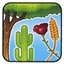

Flora
Plant
Nature


In [ ]:
from IPython.display import display
from PIL import Image
from datasets import load_dataset

hint_description = load_dataset("JettChenT/ioai-chameleon-hint_descriptions")['train']

hint_description = {
    x['ID']: {'description': x['Description'], 'icons': x['image']}
    for x in hint_description
}

# show example
display(hint_description[7]['icons'])
print(hint_description[7]['description'])

### Validation Data

You can access the validation data using the following method:


In [ ]:
validation_data = load_dataset("JettChenT/ioai-chameleon-takehome_validation")['validation']

# an example of a game.
print(validation_data[0])

{'hints': [6, 61, 63, 115, 33], 'options': ['sunflower', 'credit card', 'dinosaur', 'key', 'sundial', 'lawyer', 'doorbell', 'trash can', 'crab', 'xylophone', 'queen', 'ambulance', 'space station', 'wallet', 'market', 'orchestra', 'chocolate', 'zipper', 'rhinoceros', 'fashion', 'butterfly', 'truck', 'palm tree', 'cake', 'radio', 'seal', 'mailbox', 'magnifying glass', 'prison', 'polar bear', 'mouse', 'alumunium foil', 'harmonica', 'shell', 'boxers', 'tricycle', 'peacock', 'kettle', 'mountain', 'harbor', 'coffee', 'fireworks', 'pie', 'gravity', 'teacher', 'museum', 'bedroom', 'robe', 'sunscreen', 'robot', 'piano', 'baker', 'plankton', 'scarf', 'bee', 'mosquito', 'accountant', 'umbrella', 'janitor', 'thief', 'parrot', 'koala', 'refrigerator', 'drone', 'dining room', 'soap', 'whistle', 'bicycle', 'train tracks', 'penguin', 'octopus', 'hula hoop', 'ice skates', 'nightmare', 'diving suit', 'horseshoe', 'dynamite', 'surfboard', 'toaster', 'gloves', 'broom', 'postal worker', 'lipstick', 'sewing

### Sample Implementation

Below is a sample implementation of the `guess_words` function.


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode([
    'hello world',
    'fun and games'
])

print(f"Embedding shape: {embeddings.shape}")

Embedding shape: (2, 384)


In [ ]:
def hints_to_sentence(hints: list[int]) -> str:
  sentence = "The following hints at our target word:\n<HINT_PRIMARY>\n"
  for i, hint in enumerate(hints):
    sentence += f"{hint_description[hint]['description']}"
    if i == 0:
      sentence += "\n</HINT_PRIMARY>\n<HINT>\n"
    elif i < len(hints) - 1:
      sentence += "\n</HINT>\n<HINT>\n"
    else:
      sentence += "\n</HINT>"
  return sentence

def choice_to_doc(choice:str)->str:
  return f"Our target word: {choice}"

print(hints_to_sentence([1, 2, 3]))

The following hints at our target word:
<HINT_PRIMARY>
Human
Society
Group
</HINT_PRIMARY>
<HINT>
Human
Historical
Real
</HINT>
<HINT>
Character
Fictional
Imaginary
</HINT>


In [ ]:
def find_most_similar(query, sentences, model, top_k=10):
    # Encode query and sentences
    query_embedding = model.encode([query])
    sentence_embeddings = model.encode(sentences)

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, sentence_embeddings)[0]

    # Get top-k most similar
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'sentence': sentences[idx],
            'similarity': similarities[idx]
        })

    return results

### Basic Fine Tuning

In [ ]:
# Fine-tune the model

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader

import os
os.environ["WANDB_DISABLED"] = "true"

train_examples = []
for val in validation_data:
  train_examples.append(InputExample(texts=[hints_to_sentence(val['hints']), choice_to_doc(val['label'])], label=1))

# Create DataLoader
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=2)

# Define loss function
train_loss = losses.CosineSimilarityLoss(model)

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=5,
    output_path='./model',
    optimizer_params={'lr': 1e-6},
    weight_decay=0.01,
    save_best_model=True,
    show_progress_bar=True
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


In [ ]:
# When running inference, you would simply load the model from the ./custom-model directory

ft_model_loaded = SentenceTransformer('./model')

In [ ]:
def guess_words(hints: list[int], choices: list[str]) -> list[str]:
  query = hints_to_sentence(hints)
  results = find_most_similar(query, choices, ft_model_loaded)
  return [result['sentence'] for result in results]

## Scoring

A submission is considered correct if the secret appears among the 10 guesses returned by your system. This is evaluated using the **Hits@10** metric.

To reward guesses that rank the correct answer higher in the list, we also use the **NDCG@10** (Normalized Discounted Cumulative Gain) metric. Your final score is a weighted combination of both metrics, with **90% weight on Hits@10** and **10% on NDCG@10**.

### Hits@10

This metric evaluates whether the correct answer appears in the list of 10 guesses:

- **Hits@10 = 1** if the correct answer is in the list of 10 guesses  
- **Hits@10 = 0** otherwise

### NDCG@10 (Normalized Discounted Cumulative Gain)

This metric gives partial credit based on how highly the correct answer is ranked. If the correct answer appears at rank *i* (1-based indexing), then:

$$
\text{NDCG@10} = \frac{1}{\log_2(i + 1)}
$$

**Examples:**

- Rank 1 → 1.00  
- Rank 2 → ~0.63  
- Rank 4 → ~0.43  
- Rank 10 → ~0.29

### Final Score

The final score combines both metrics:
$$
\text{Final Score} = 0.9 \times \text{Hits@10} + 0.1 \times \text{NDCG@10}
$$

The following function will calculate your score:

In [ ]:
import math

def score(guesses: list[str], gold: str):
    # Normalize to lowercase
    guesses = [g.lower() for g in guesses[:10]]
    gold = gold.lower()

    result = {
        "hits@10": 0.0,
        "ndcg@10": 0.0,
        "total_score": 0.0
    }

    if gold in guesses:
        rank = guesses.index(gold)
        result["hits@10"] = 1.0
        result["ndcg@10"] = 1.0 / math.log2(rank + 2)  # rank + 2 because index is 0-based
    else:
        result["hits@10"] = 0.0
        result["ndcg@10"] = 0.0

    result["total_score"] = 0.9 * result["hits@10"] + 0.1 * result["ndcg@10"]
    return result

print(score(['cat', 'dog', 'tree', 'flower', 'rock', 'water', 'fried rice', 'airplane', 'cactus', 'tiger'], gold='cactus'))

{'hits@10': 1.0, 'ndcg@10': 0.3010299956639812, 'total_score': 0.9301029995663982}


In [ ]:
from tqdm.notebook import tqdm

# score on validation set
guesses = []
total_scores = 0.0
for example in tqdm(validation_data):
    guesses.append(guess_words(example['hints'], example['options']))

    total_scores += score(guesses[-1], example['label'])['total_score']


print(f"Average validation score: {total_scores / len(validation_data)}")

  0%|          | 0/20 [00:00<?, ?it/s]

Average validation score: 0.43332619062387023
